# Обучение и экспорт модели улучшения изображений
Модель предсказывает три параметра коррекции изображения: brightness, contrast, saturation.

contrast и saturation обучаются в логарифмическом пространстве: это мультипликативные
величины, и без логарифма ошибка на больших значениях доминирует в loss непропорционально сильно

## 1. Датасет

EnhanceDataset читает синтетически деградированные изображения и
целевые параметры коррекции из targets.json

In [69]:
import json
import numpy as np
import torch
from torch.utils.data import Dataset
from pathlib import Path
from PIL import Image
import torchvision.transforms as T


class EnhanceDataset(Dataset):
    def __init__(self, split_dir, img_size=224):
        self.split_dir = Path(split_dir)
        self.img_dir = self.split_dir / "degraded"

        with open(self.split_dir / "targets.json") as f:
            self.targets = json.load(f)

        self.files = sorted(self.img_dir.glob("*.jpg"))
        self.files = [f for f in self.files if f.name in self.targets]

        self.transform = T.Compose([
            T.Resize((img_size, img_size)),
            T.ToTensor(),
        ])

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        f = self.files[idx]
        img = self.transform(Image.open(f).convert("RGB"))

        t = self.targets[f.name]
        target = torch.tensor([
            t["brightness"],
            np.log(t["contrast"]),
            np.log(t["saturation"]),
        ], dtype=torch.float32)
        return img, target

    def severity_counts(self):
        from collections import Counter
        return Counter(self.targets[f.name].get("severity", "unknown") for f in self.files)


## 2. Модель

TinyEnhanceNet - CNN: 5 свёрточных блоков (Conv+BatchNorm+ReLU, stride=2)
сжимают 224×224 до вектора признаков, затем полносвязная голова выдаёт 3 числа

Множители в tanh(x) * K подобраны под фактические диапазоны целевых значений
с запасом примерно 15-20%, чтобы активация не "упиралась" в потолок на экстремальных примерах деградации.

In [70]:
import torch
import torch.nn as nn


class TinyEnhanceNet(nn.Module):
    def __init__(self):
        super().__init__()

        def block(cin, cout, stride=2):
            return nn.Sequential(
                nn.Conv2d(cin, cout, 3, stride=stride, padding=1, bias=False),
                nn.BatchNorm2d(cout),
                nn.ReLU(inplace=True),
            )

        self.features = nn.Sequential(
            block(3, 16),    # 224 -> 112
            block(16, 32),   # 112 -> 56
            block(32, 64),   # 56 -> 28
            block(64, 96),   # 28 -> 14
            block(96, 128),  # 14 -> 7
        )
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 32),
            nn.ReLU(inplace=True),
            nn.Dropout(0.1),
            nn.Linear(32, 3),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = self.head(x)

        brightness = torch.tanh(x[:, 0:1]) * 3.0
        log_contrast = torch.tanh(x[:, 1:2]) * 2.5
        log_saturation = torch.tanh(x[:, 2:3]) * 3.3

        return torch.cat([brightness, log_contrast, log_saturation], dim=1)


## 3. Проверка диапазонов целевых значений

Перед обучением стоит убедиться, что множители в forward() действительно
покрывают фактический диапазон targets.json с запасом - иначе модель физически не
сможет предсказать экстремальные значения

In [71]:
DATA_ROOT = "/kaggle/input/datasets/olesya25/synthetic-images/synthetic"

for split in ["train", "val", "test"]:
    with open(f"{DATA_ROOT}/{split}/targets.json") as f:
        targets = json.load(f)

    for key in ["brightness", "contrast", "saturation"]:
        vals = [t[key] for t in targets.values()]
        print(f"{split}/{key}: min={min(vals):.3f} max={max(vals):.3f}")

    for key in ["contrast", "saturation"]:
        log_vals = [np.log(t[key]) for t in targets.values()]
        print(f"{split}/log_{key}: min={min(log_vals):.3f} max={max(log_vals):.3f}")


train/brightness: min=-2.523 max=2.671
train/contrast: min=0.313 max=4.987
train/saturation: min=0.286 max=19.997
train/log_contrast: min=-1.163 max=1.607
train/log_saturation: min=-1.251 max=2.996
val/brightness: min=-2.129 max=2.303
val/contrast: min=0.315 max=4.956
val/saturation: min=0.286 max=18.821
val/log_contrast: min=-1.154 max=1.601
val/log_saturation: min=-1.252 max=2.935
test/brightness: min=-2.210 max=2.388
test/contrast: min=0.315 max=4.846
test/saturation: min=0.299 max=19.632
test/log_contrast: min=-1.156 max=1.578
test/log_saturation: min=-1.208 max=2.977


## 4. Обучение

- Взвешенный Huber loss - базовая устойчивость Huber
  к выбросам плюс дополнительный вес для примеров с экстремальными log_contrast/
  log_saturation.

  Причина: диагностика худших примеров (раздел 9, предыдущий прогон)
  показала систематическую недооценку contrast моделью именно на примерах с
  высоким истинным значением - обычный Huber "стягивает" предсказания к центру
  распределения, т.к. редкие экстремальные примеры вносят пропорционально меньший
  вклад в средний loss.
- ReduceLROnPlateau - снижает learning rate, если val_loss перестал улучшаться.
- Early stopping (patience=15) - останавливает обучение без прогресса.
- Чекпоинты сохраняются в best_model.pt (лучший по val), last_model.pt
  (последняя эпоха) и interrupted_model.pt (если обучение прервано вручную).

In [72]:
def weighted_huber_loss(pred, target, delta=0.5):
    diff = pred - target
    abs_diff = diff.abs()
    quadratic = torch.clamp(abs_diff, max=delta)
    linear = abs_diff - quadratic
    base_loss = 0.5 * quadratic ** 2 + delta * linear
    extremity = target[:, 1:3].abs().max(dim=1).values
    sample_weight = 1.0 + extremity

    per_sample_loss = base_loss.sum(dim=1) * sample_weight
    return per_sample_loss.mean()


Устройство: cuda
train: 5040 примеров, {'unknown': 5040}
val:   270 примеров, {'unknown': 270}
epoch 000  train_loss=0.92100  val_loss=1.04728  lr=1.00e-03
  -> новый лучший чекпоинт (val_loss=1.04728)
epoch 001  train_loss=0.78301  val_loss=1.03475  lr=1.00e-03
  -> новый лучший чекпоинт (val_loss=1.03475)
epoch 002  train_loss=0.74696  val_loss=0.86240  lr=1.00e-03
  -> новый лучший чекпоинт (val_loss=0.86240)
epoch 003  train_loss=0.68858  val_loss=0.71049  lr=1.00e-03
  -> новый лучший чекпоинт (val_loss=0.71049)
epoch 004  train_loss=0.66776  val_loss=0.67213  lr=1.00e-03
  -> новый лучший чекпоинт (val_loss=0.67213)
epoch 005  train_loss=0.64605  val_loss=0.57492  lr=1.00e-03
  -> новый лучший чекпоинт (val_loss=0.57492)
epoch 006  train_loss=0.58241  val_loss=0.56403  lr=1.00e-03
  -> новый лучший чекпоинт (val_loss=0.56403)
epoch 007  train_loss=0.56539  val_loss=0.51478  lr=1.00e-03
  -> новый лучший чекпоинт (val_loss=0.51478)
epoch 008  train_loss=0.53717  val_loss=0.43624  

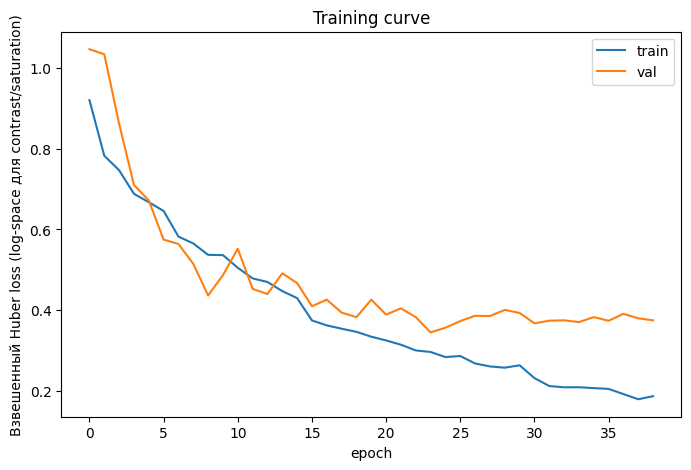

Готово. Лучшая модель: /kaggle/working/best_model.pt (val_loss=0.34467)


In [73]:
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Устройство: {device}")

CHECKPOINT_DIR = Path("/kaggle/working")
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

train_ds = EnhanceDataset(f"{DATA_ROOT}/train")
val_ds = EnhanceDataset(f"{DATA_ROOT}/val")

print(f"train: {len(train_ds)} примеров, {dict(train_ds.severity_counts())}")
print(f"val:   {len(val_ds)} примеров, {dict(val_ds.severity_counts())}")

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=2, pin_memory=(device == "cuda"))
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=2, pin_memory=(device == "cuda"))

model = TinyEnhanceNet().to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=0.5, patience=5)
loss_fn = weighted_huber_loss

N_EPOCHS = 80
PATIENCE = 15
best_val = float("inf")
epochs_without_improvement = 0
history = {"train_loss": [], "val_loss": []}

try:
    for epoch in range(N_EPOCHS):
        model.train()
        train_loss = 0.0
        for imgs, targets in train_loader:
            imgs, targets = imgs.to(device), targets.to(device)
            opt.zero_grad()
            pred = model(imgs)
            loss = loss_fn(pred, targets)
            loss.backward()
            opt.step()
            train_loss += loss.item() * imgs.size(0)
        train_loss /= len(train_ds)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for imgs, targets in val_loader:
                imgs, targets = imgs.to(device), targets.to(device)
                pred = model(imgs)
                val_loss += loss_fn(pred, targets).item() * imgs.size(0)
        val_loss /= len(val_ds)

        scheduler.step(val_loss)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        current_lr = opt.param_groups[0]["lr"]
        print(f"epoch {epoch:03d}  train_loss={train_loss:.5f}  val_loss={val_loss:.5f}  lr={current_lr:.2e}")

        if val_loss < best_val:
            best_val = val_loss
            epochs_without_improvement = 0
            torch.save(model.state_dict(), CHECKPOINT_DIR / "best_model.pt")
            print(f"  -> новый лучший чекпоинт (val_loss={val_loss:.5f})")
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= PATIENCE:
                print(f"Early stopping на эпохе {epoch}")
                break

        torch.save(model.state_dict(), CHECKPOINT_DIR / "last_model.pt")

except KeyboardInterrupt:
    print("\nОбучение прервано вручную — сохраняю текущее состояние")
    torch.save(model.state_dict(), CHECKPOINT_DIR / "interrupted_model.pt")

with open(CHECKPOINT_DIR / "history.json", "w") as f:
    json.dump(history, f, indent=2)

plt.figure(figsize=(8, 5))
plt.plot(history["train_loss"], label="train")
plt.plot(history["val_loss"], label="val")
plt.xlabel("epoch")
plt.ylabel("Взвешенный Huber loss")
plt.legend()
plt.title("Training curve")
plt.savefig(CHECKPOINT_DIR / "training_curve.png")
plt.show()

print(f"Готово. Лучшая модель: {CHECKPOINT_DIR / 'best_model.pt'} (val_loss={best_val:.5f})")


## 5. Экспорт в ONNX

In [82]:
!pip install onnxscript

In [83]:
model = TinyEnhanceNet()
model.load_state_dict(torch.load(CHECKPOINT_DIR / "best_model.pt", map_location="cpu"))
model.eval()

dummy = torch.randn(1, 3, 224, 224)
torch.onnx.export(
    model, dummy, "model_fp32.onnx",
    input_names=["input"], output_names=["params"],
    opset_version=17,
    dynamo=False,
)
print("Экспортировано в model_fp32.onnx")


Экспортировано в model_fp32.onnx


/tmp/ipykernel_58/34697661.py:6: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(


## 6. Квантизация (float32 → int8)

Уменьшает размер модели в 2-4 раза почти без потери точности - важно для 
"суммарный код ≤ 10 МБ" из ТЗ.

In [84]:
!pip install onnxruntime

In [85]:
from onnxruntime.quantization import quantize_dynamic, QuantType

quantize_dynamic(
    model_input="model_fp32.onnx",
    model_output="model_int8.onnx",
    weight_type=QuantType.QInt8,
)

import os
print(f"fp32: {os.path.getsize('model_fp32.onnx') / 1024:.1f} КБ")
print(f"int8: {os.path.getsize('model_int8.onnx') / 1024:.1f} КБ")

fp32: 762.6 КБ
int8: 207.6 КБ


## 7. Быстрая проверка на одном изображении

In [86]:
import cv2
import onnxruntime as ort

sess = ort.InferenceSession("model_int8.onnx")

img = cv2.imread(f"{DATA_ROOT}/test/degraded/0047_v2.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (224, 224)).astype(np.float32) / 255.0
tensor = np.transpose(img, (2, 0, 1))[None, ...]

out = sess.run(None, {"input": tensor})[0][0]
brightness, contrast, saturation = out[0], np.exp(out[1]), np.exp(out[2])
print(f"brightness={brightness:.3f} contrast={contrast:.3f} saturation={saturation:.3f}")


brightness=0.161 contrast=0.639 saturation=5.166


## 8. Оценка качества на тестовой выборке

Сравниваем результат коррекции с предсказанными моделью параметрами против
результата с истинными параметрами.

In [87]:
from pathlib import Path
from tqdm import tqdm

TEST_DIR = Path(f"{DATA_ROOT}/test")


def apply_correction(img, brightness, contrast, saturation):
    # img: float32 HWC в [0,1]. Порядок ОБЯЗАН совпадать с correction.ts:
    # сначала brightness+contrast, потом saturation.
    out = np.clip((img - 0.5) * contrast + 0.5 + brightness, 0, 1)
    lum = (0.299 * out[..., 0] + 0.587 * out[..., 1] + 0.114 * out[..., 2])[..., None]
    return np.clip(lum + (out - lum) * saturation, 0, 1)


def predict(img_224):
    tensor = np.transpose(img_224, (2, 0, 1))[None, ...].astype(np.float32)
    out = sess.run(None, {"input": tensor})[0][0]
    return float(out[0]), float(np.exp(out[1])), float(np.exp(out[2]))


with open(TEST_DIR / "targets.json") as f:
    targets = json.load(f)

psnr_scores = []
mae = {"brightness": [], "contrast": [], "saturation": []}
severity_psnr = {}

for name, t in tqdm(targets.items()):
    path = TEST_DIR / "degraded" / name
    if not path.exists():
        continue

    img_full = cv2.cvtColor(cv2.imread(str(path)), cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
    img_224 = cv2.resize(img_full, (224, 224))

    pred_b, pred_c, pred_s = predict(img_224)
    true_b, true_c, true_s = t["brightness"], t["contrast"], t["saturation"]

    mae["brightness"].append(abs(pred_b - true_b))
    mae["contrast"].append(abs(np.log(pred_c) - np.log(true_c)))
    mae["saturation"].append(abs(np.log(pred_s) - np.log(true_s)))

    result_pred = apply_correction(img_full, pred_b, pred_c, pred_s)
    result_true = apply_correction(img_full, true_b, true_c, true_s)
    psnr = cv2.PSNR((result_pred * 255).astype(np.uint8), (result_true * 255).astype(np.uint8))
    psnr_scores.append(psnr)

    severity_psnr.setdefault(t.get("severity", "unknown"), []).append(psnr)

print(f"\nВсего изображений: {len(psnr_scores)}")
print(f"Средний PSNR: {np.mean(psnr_scores):.2f} дБ (медиана: {np.median(psnr_scores):.2f})")
print(f"Мин/макс PSNR: {np.min(psnr_scores):.2f} / {np.max(psnr_scores):.2f}")

print("\nMAE по каналам:")
print(f"  brightness (линейная шкала): {np.mean(mae['brightness']):.4f}")
print(f"  contrast   (лог-шкала):      {np.mean(mae['contrast']):.4f}")
print(f"  saturation (лог-шкала):      {np.mean(mae['saturation']):.4f}")

print("\nPSNR по severity:")
for sev, scores in severity_psnr.items():
    print(f"  {sev}: среднее={np.mean(scores):.2f} дБ, n={len(scores)}")


100%|██████████| 270/270 [01:27<00:00,  3.10it/s]


Всего изображений: 270
Средний PSNR: 19.42 дБ (медиана: 18.87)
Мин/макс PSNR: 7.19 / 38.30

MAE по каналам:
  brightness (линейная шкала): 0.1245
  contrast   (лог-шкала):      0.2860
  saturation (лог-шкала):      0.4981

PSNR по severity:
  unknown: среднее=19.42 дБ, n=270


## 9. Топ-10 худших примеров

Точечная диагностика: смотрим, где именно модель ошибается сильнее всего, и
сравниваем предсказанные параметры с истинными 

In [88]:
results = []
for name, t in targets.items():
    path = TEST_DIR / "degraded" / name
    if not path.exists():
        continue

    img_full = cv2.cvtColor(cv2.imread(str(path)), cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
    img_224 = cv2.resize(img_full, (224, 224))
    pred_b, pred_c, pred_s = predict(img_224)
    true_b, true_c, true_s = t["brightness"], t["contrast"], t["saturation"]

    result_pred = apply_correction(img_full, pred_b, pred_c, pred_s)
    result_true = apply_correction(img_full, true_b, true_c, true_s)
    psnr = cv2.PSNR((result_pred * 255).astype(np.uint8), (result_true * 255).astype(np.uint8))

    results.append((name, psnr, true_b, true_c, true_s, pred_b, pred_c, pred_s))

results.sort(key=lambda x: x[1]) 

print("10 худших по PSNR:")
for r in results[:10]:
    print(f"{r[0]}: PSNR={r[1]:.1f}  true=(b={r[2]:.2f},c={r[3]:.2f},s={r[4]:.2f})  "
          f"pred=(b={r[5]:.2f},c={r[6]:.2f},s={r[7]:.2f})")

print("\n10 худших по ошибке saturation (лог-шкала):")
sat_errors = sorted(
    ((r[0], abs(np.log(r[7]) - np.log(r[4])), r[4], r[7], r[1]) for r in results),
    key=lambda x: -x[1],
)
for name, err, true_s, pred_s, psnr in sat_errors[:10]:
    print(f"{name}: log_err={err:.3f}  true_s={true_s:.2f}  pred_s={pred_s:.2f}  PSNR={psnr:.1f}")


10 худших по PSNR:
0251_v2.jpg: PSNR=7.2  true=(b=0.47,c=3.72,s=0.78)  pred=(b=0.90,c=3.65,s=0.79)
0575_v2.jpg: PSNR=8.6  true=(b=-2.21,c=4.29,s=1.62)  pred=(b=-1.76,c=4.08,s=0.88)
0104_v1.jpg: PSNR=8.7  true=(b=0.78,c=2.46,s=10.62)  pred=(b=0.53,c=1.06,s=15.08)
0115_v0.jpg: PSNR=9.0  true=(b=-0.66,c=2.84,s=0.55)  pred=(b=-0.25,c=2.34,s=0.51)
0666_v2.jpg: PSNR=9.4  true=(b=0.44,c=2.60,s=2.86)  pred=(b=0.55,c=1.89,s=6.93)
0026_v2.jpg: PSNR=10.2  true=(b=1.49,c=3.63,s=10.17)  pred=(b=0.88,c=1.60,s=11.17)
0115_v1.jpg: PSNR=11.2  true=(b=-0.19,c=1.07,s=0.78)  pred=(b=0.05,c=0.87,s=0.74)
0301_v1.jpg: PSNR=11.2  true=(b=-0.47,c=1.88,s=0.59)  pred=(b=-0.19,c=1.95,s=0.46)
0592_v2.jpg: PSNR=11.3  true=(b=0.33,c=0.78,s=0.73)  pred=(b=0.05,c=0.71,s=1.22)
0792_v0.jpg: PSNR=11.6  true=(b=0.25,c=0.48,s=0.93)  pred=(b=0.02,c=0.43,s=7.53)

10 худших по ошибке saturation (лог-шкала):
0792_v2.jpg: log_err=2.327  true_s=0.77  pred_s=7.93  PSNR=18.9
0297_v0.jpg: log_err=2.115  true_s=19.63  pred_s=2.37  P

## 10. Экспорт весов для браузера (без ONNX Runtime)

onnxruntime-web даёт WASM-бандл весом от 13 МБ даже в самой лёгкой конфигурации —
не укладывается в бюджет 10 МБ на весь код. 

Решение: выгрузить веса в JSON и реализовать forward pass вручную на TypeScript.

In [89]:
def fuse_conv_bn(conv, bn, eps=1e-5):
    # Возвращает (weight, bias) для эквивалентного Conv2d с bias, без отдельного BatchNorm.
    gamma = bn.weight.detach()
    beta = bn.bias.detach()
    mean = bn.running_mean.detach()
    var = bn.running_var.detach()
    scale = gamma / torch.sqrt(var + eps)

    weight = conv.weight.detach() * scale.view(-1, 1, 1, 1)
    bias = beta - mean * scale
    return weight, bias


model = TinyEnhanceNet()
model.load_state_dict(torch.load(CHECKPOINT_DIR / "best_model.pt", map_location="cpu"))
model.eval()

blocks = []
for seq in model.features:
    conv, bn, _ = seq[0], seq[1], seq[2]  # Conv2d, BatchNorm2d, ReLU
    weight, bias = fuse_conv_bn(conv, bn)
    blocks.append({
        "weight": weight.flatten().tolist(),
        "bias": bias.flatten().tolist(),
        "cout": weight.shape[0],
        "cin": weight.shape[1],
        "k": weight.shape[2],
        "stride": 2,
    })

fc1, fc2 = model.head[1], model.head[4]  # Linear(128, 32), Linear(32, 3)

export = {
    "blocks": blocks,
    "fc1": {
        "weight": fc1.weight.detach().flatten().tolist(),
        "bias": fc1.bias.detach().flatten().tolist(),
        "in": fc1.in_features,
        "out": fc1.out_features,
    },
    "fc2": {
        "weight": fc2.weight.detach().flatten().tolist(),
        "bias": fc2.bias.detach().flatten().tolist(),
        "in": fc2.in_features,
        "out": fc2.out_features,
    },
}

with open("weights.json", "w") as f:
    json.dump(export, f)

print(f"Размер weights.json: {os.path.getsize('weights.json') / 1024:.1f} КБ")


Размер weights.json: 4208.5 КБ
